# Ropedia Academy — A4 · 3D human mesh recovery

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/A4.ipynb)

> **Trains HMR by reprojection (3D supervised through 2D) and visualizes the loss curve plus reprojected joints landing on the 2D labels.**
>
> 用重投影训练 HMR（经 2D 监督 3D），并可视化损失曲线，以及重投影关节落到 2D 标注上的过程。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/A4

trained from 2D keypoints only; final loss: 0.019


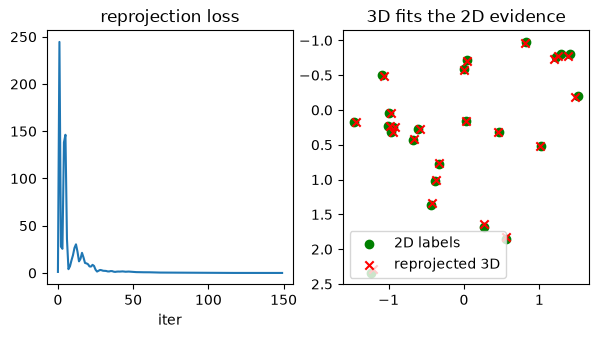

In [1]:
import torch, torch.nn as nn, matplotlib.pyplot as plt
# HMR: regress SMPL params + camera, train with NO 3D labels (reprojection loss).

# ---------- INPUT: an image feature + abundant 2D keypoint labels ----------
img_feat = torch.randn(1, 512)                  # from a CNN/ViT backbone
kp2d_gt  = torch.randn(24, 2)                    # the only supervision (2D labels)
head = nn.Linear(512, 10 + 24*3 + 3)            # -> beta(10) + theta(72) + cam(s,tx,ty)

# ---------- MODEL: regress params, project 3D->2D, minimize reprojection + prior ----------
def project(j3d, cam):
    return cam[0] * j3d[:, :2] + cam[1:]         # weak-perspective: 3D joints -> 2D
hist = []; opt = torch.optim.Adam(head.parameters(), 1e-2)
for _ in range(150):
    opt.zero_grad()
    o = head(img_feat)[0]; j = o[10:82].reshape(24,3); c = o[82:]
    loss = ((project(j, c) - kp2d_gt)**2).mean() + 0.1*(o[10:82]**2).mean()  # reproj + prior
    loss.backward(); opt.step(); hist.append(loss.item())

# ---------- OUTPUT: loss curve + reprojected joints landing on the 2D labels ----------
print("trained from 2D keypoints only; final loss:", round(hist[-1], 3))
fig, ax = plt.subplots(1, 2, figsize=(7, 3.3))
ax[0].plot(hist); ax[0].set_title("reprojection loss"); ax[0].set_xlabel("iter")
o = head(img_feat)[0]; proj = project(o[10:82].reshape(24,3), o[82:]).detach()
ax[1].scatter(*kp2d_gt.T, c='g', label='2D labels')
ax[1].scatter(*proj.T, c='r', marker='x', label='reprojected 3D')
ax[1].legend(); ax[1].invert_yaxis(); ax[1].set_title("3D fits the 2D evidence"); plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/A4
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks